In [1]:
import sys
sys.path.append('/Users/aidanmorson/Desktop/analysis/parkinsons/analysis')

In [2]:
from analysis.position_sd import get_neuron_positions, compute_2d_histogram, compute_2d_kde
from analysis.stats_sd import reduce_dimensionality
from load_data.load_npz import load_spikedata
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import os
import numpy as np


In [3]:
sd24578_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24578_D49-6.zip')
sd24578_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24578_D60+6.zip')
sd24481_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24481_D49-6.zip')
sd24481_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24481_D60+6.zip')

In [127]:
def plot_waveform_layout(neuron_id, sd, mean_fr=None, axs=None, ylim_margin=0):
    """
    Plot the waveform layout for a given neuron across all electrodes.
    
    Parameters:
      neuron_id : int
          The neuron ID to plot.
      sd : SpikeData object
          The SpikeData object containing neuron_data.
      mean_fr : float, optional
          The mean firing rate (Hz) for this neuron. If provided, it is added to the title.
      axs : matplotlib.axes.Axes, optional
          The axes on which to plot. If None, a new figure is created.
      ylim_margin : float, optional
          Additional margin for the y-limits in the inset plots.
    
    Returns:
      matplotlib.axes.Axes: The axes on which the plot was drawn.
    """
    if axs is None:
        fig, axs = plt.subplots(1, 1, figsize=(6,6))
    
    # Retrieve data for this neuron.
    data = sd.neuron_attributes
    k = neuron_id
    ch = data["channel"][k]
    position = data["position"][k]
    temp_chs = list(data["neighbor_channels"][k])
    temp_pos = data["neighbor_positions"][k]
    templates = data["neighbor_templates"][k]
    # Using a unique id for filename or title; here we use the neuron_id.
    filename = f"Neuron_{neuron_id}"
    nelec = 2
    
    # Build the title including the mean firing rate if provided.
    title_str = f"{filename} cluster {k} channel {ch} {position}"
    if mean_fr is not None:
        title_str += f" (FR: {mean_fr:.1f} Hz)"
    
    axs.set_title(title_str)
    assert len(temp_chs) == len(temp_pos) == len(templates), "Input length should be the same!"
    nums = len(temp_chs)
    pitch = 17.5
    # Plot the main neuron position as a semi-transparent grey dot.
    axs.scatter(position[0], position[1], linewidth=10, alpha=0.2, color='grey')
    axs.text(position[0], position[1], str(position), color="g", fontsize=12)
    
    # Use the channel of interest to set y-axis limits for the insets.
    index = temp_chs.index(ch)
    ylim_min = min(templates[index])
    ylim_max = max(templates[index])
    
    # Draw insets for each neighboring channel within a certain range.
    for i in range(nums):
        chn_pos = temp_pos[i]
        if (position[0] - nelec * pitch <= chn_pos[0] <= position[0] + nelec * pitch and
            position[1] - nelec * pitch <= chn_pos[1] <= position[1] + nelec * pitch):
            # Create an inset axis at the neighbor's position.
            axin = axs.inset_axes([chn_pos[0]-5, chn_pos[1]-5, 15, 20], transform=axs.transData)
            axin.plot(templates[i], color='k', linewidth=2, alpha=0.7)
            axin.set_ylim([ylim_min - ylim_margin, ylim_max + ylim_margin])
            axin.set_axis_off()
    
    # Draw a line connecting the main neuron to all in-range neighbors.
    for pos in temp_pos:
        if (position[0] - nelec * pitch <= pos[0] <= position[0] + nelec * pitch and
            position[1] - nelec * pitch <= pos[1] <= position[1] + nelec * pitch):
            axs.plot([position[0], pos[0]], [position[1], pos[1]], color='gray', linestyle='--', alpha=0.5)
    
    axs.set_xlim(position[0] - 1.5 * nelec * pitch, position[0] + 1.5 * nelec * pitch)
    axs.set_ylim(position[1] - 1.5 * nelec * pitch, position[1] + 1.5 * nelec * pitch)
    axs.invert_yaxis()
    axs.set_xlabel("Horizontal Position (um)")
    axs.set_ylabel("Vertical Position (um)")
    return axs

def plot_all_waveform_layouts(sd, output_path, neuron_ids=None, ylim_margin=0):
    """
    Plot waveform layout for all neurons in a SpikeData object (or a subset specified by neuron_ids).
    Each plot is saved to the output_path with a filename that includes the neuron id.
    
    Additionally, each plot includes a legend entry for the neuron's mean firing rate.
    
    Parameters:
      sd : SpikeData object
          The SpikeData object containing neuron_data.
      output_path : str
          Directory path where each plot will be saved.
      neuron_ids : list of int, optional
          List of neuron IDs to plot. If None, all neuron IDs in sd.neuron_data[0] are plotted.
      ylim_margin : float, optional
          Margin added to the y-axis limits for inset plots.
    """
    from analysis.firing_sd import mean_firing_rates  # Ensure this is the correct import
    
    # Get mean firing rates for all neurons.
    fr_array = mean_firing_rates(sd)  # 1D array indexed by neuron id
    # Get list of all neuron IDs from the dictionary keys in sd.neuron_data[0]
    all_neuron_ids = list(range(0, sd.N))
    if neuron_ids is None:
        neuron_ids = all_neuron_ids

    
    os.makedirs(output_path, exist_ok=True)
    
    for nid in neuron_ids:
        # Get the mean firing rate for this neuron
        mean_fr = fr_array[nid] if nid < len(fr_array) else None
        # Create the plot for this neuron
        axs = plot_waveform_layout(nid, sd, mean_fr=mean_fr, ylim_margin=ylim_margin)
        # Save the figure with a filename that includes the neuron id
        filename = f"waveform_layout_neuron_{nid}.png"
        save_path = os.path.join(output_path, filename)
        plt.savefig(save_path)
        plt.close()
        print(f"Saved waveform layout for neuron {nid} to {save_path}")


In [128]:
from analysis.firing_sd import mean_firing_rates
fr = mean_firing_rates(sd24578_49)
fr16 = fr[16]
print(fr[:17])
print(fr16)

[ 0.55128767  2.33635715  2.34407517  2.31320306  3.69252481  6.31114125
  2.4322812  10.45461938  5.20636076  7.37512645  2.20845841  2.42897347
  0.60090356 10.16464206  9.69604754  4.44227605  5.06633369]
5.066333688913881


<Axes: title={'center': 'Neuron_16 cluster 16 channel 441 [1470.   787.5] (FR: 5.1 Hz)'}, xlabel='Horizontal Position (um)', ylabel='Vertical Position (um)'>

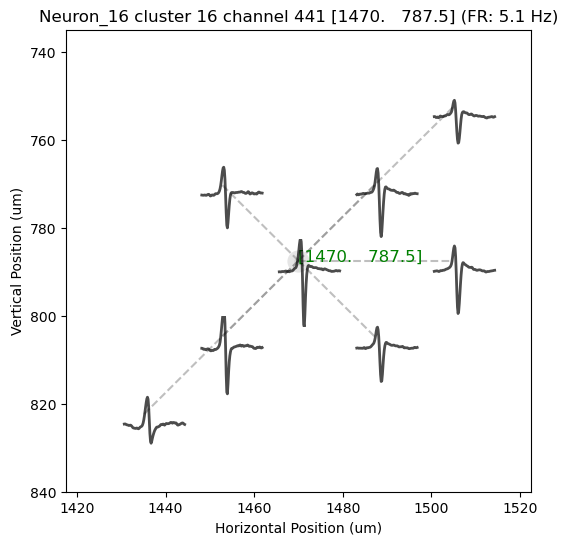

In [129]:
plot_waveform_layout(16, sd24578_49, fr16)

In [45]:
plot_all_waveform_layouts(sd24578_49, '/Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D49')

Saved waveform layout for neuron 0 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D49/waveform_layout_neuron_0.png
Saved waveform layout for neuron 1 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D49/waveform_layout_neuron_1.png
Saved waveform layout for neuron 2 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D49/waveform_layout_neuron_2.png
Saved waveform layout for neuron 3 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D49/waveform_layout_neuron_3.png
Saved waveform layout for neuron 4 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D49/waveform_layout_neuron_4.png
Saved waveform layout for neuron 5 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D49/waveform_layout_neuron_5.png
Saved waveform layout for neuron 6 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D49/waveform_layout_neuron_6.png
Saved wavefor

In [47]:
plot_all_waveform_layouts(sd24578_60, '/Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D60')

Saved waveform layout for neuron 0 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D60/waveform_layout_neuron_0.png
Saved waveform layout for neuron 1 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D60/waveform_layout_neuron_1.png
Saved waveform layout for neuron 2 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D60/waveform_layout_neuron_2.png
Saved waveform layout for neuron 3 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D60/waveform_layout_neuron_3.png
Saved waveform layout for neuron 4 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D60/waveform_layout_neuron_4.png
Saved waveform layout for neuron 5 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D60/waveform_layout_neuron_5.png
Saved waveform layout for neuron 6 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24578_D60/waveform_layout_neuron_6.png
Saved wavefor

In [130]:
plot_all_waveform_layouts(sd24481_49, '/Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D49')

Saved waveform layout for neuron 0 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D49/waveform_layout_neuron_0.png
Saved waveform layout for neuron 1 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D49/waveform_layout_neuron_1.png
Saved waveform layout for neuron 2 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D49/waveform_layout_neuron_2.png
Saved waveform layout for neuron 3 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D49/waveform_layout_neuron_3.png
Saved waveform layout for neuron 4 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D49/waveform_layout_neuron_4.png
Saved waveform layout for neuron 5 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D49/waveform_layout_neuron_5.png
Saved waveform layout for neuron 6 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D49/waveform_layout_neuron_6.png
Saved wavefor

In [131]:
plot_all_waveform_layouts(sd24481_60, '/Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D60')

Saved waveform layout for neuron 0 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D60/waveform_layout_neuron_0.png
Saved waveform layout for neuron 1 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D60/waveform_layout_neuron_1.png
Saved waveform layout for neuron 2 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D60/waveform_layout_neuron_2.png
Saved waveform layout for neuron 3 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D60/waveform_layout_neuron_3.png
Saved waveform layout for neuron 4 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D60/waveform_layout_neuron_4.png
Saved waveform layout for neuron 5 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D60/waveform_layout_neuron_5.png
Saved waveform layout for neuron 6 to /Users/aidanmorson/Desktop/analysis/parkinsons/waveform_layouts/24481_D60/waveform_layout_neuron_6.png
Saved wavefor